# Morph-value sweep analysis

Relates morphology (**leg count**, **segment lengths**) to outcome (**episode reward**) and to the
critic's **value estimate**, across the ant-full checkpoints in `STEMS`, each rolled over `N`
**Samples** (fresh 4096-morph draws). Data from `test --data-type full` — see `experiments/CONTEXT.md`
and `docs/adr/0007`. Value is in **raw-reward units**; the per-env value scalar is **mean V over the
episode**. Leg count is encoded by a consistent light→dark **purple** gradient throughout.

### Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr, pearsonr

DATA_DIR = Path("../data/morph_value_sweep")
OUT_DIR  = DATA_DIR

# One stem per checkpoint = the run-dir name (or --name) the harness keyed the .npz by. EDIT THESE.
STEMS = [
    "CorrelationExperimentS1",
    "CorrelationExperimentS2",
    "CorrelationExperimentS3",
]

def load_model(stem):
    d = np.load(DATA_DIR / f"{stem}_traces.npz", allow_pickle=True)
    return {
        "stem": stem,
        "value":          d["value"],           # [S, N, L]  raw-reward units, nan = post-episode pad
        "reward_step":    d["reward"],          # [S, N, L]  per-step raw reward
        "leg_count":      d["leg_count"],       # [S, N]
        "lengths":        d["lengths"],         # [S, N, 16] hip_1..8, ankle_1..8 (0 = inactive slot)
        "episode_reward": d["episode_reward"],  # [S, N]
        "episode_len":    d["episode_len"],     # [S, N]
        "terminated":     d["terminated"],      # [S, N]  True=term, False=trunc
        # float32 cast first: summing ~1000 float16 steps overflows (>65504) -> inf mean_v.
        "mean_v":         np.nanmean(d["value"].astype(np.float32), axis=2),  # [S, N] mean V/episode
        "reward_scale":   float(d["reward_scale"]),
        "max_ep":         int(d["max_episode_length"]),
    }

models = [load_model(s) for s in STEMS]
for m in models:
    print(f'{m["stem"]:>24}  value{m["value"].shape}  envs={m["episode_reward"].size}')

 CorrelationExperimentS1  value(5, 4096, 1001)  envs=20480
 CorrelationExperimentS2  value(5, 4096, 1001)  envs=20480
 CorrelationExperimentS3  value(5, 4096, 1001)  envs=20480


In [2]:
# Per-env table (one row per model x sample x env). Mean *active* segment lengths + mean V.
def env_frame(m):
    S, N, _ = m["lengths"].shape
    hip = np.where(m["lengths"][:, :, :8] > 0, m["lengths"][:, :, :8], np.nan)
    ank = np.where(m["lengths"][:, :, 8:] > 0, m["lengths"][:, :, 8:], np.nan)
    return pd.DataFrame({
        "model":          m["stem"],
        "sample":         np.repeat(np.arange(S), N),
        "env":            np.tile(np.arange(N), S),
        "leg_count":      m["leg_count"].reshape(-1),
        "reward":         m["episode_reward"].reshape(-1),
        "episode_len":    m["episode_len"].reshape(-1),
        "terminated":     m["terminated"].reshape(-1),
        "mean_v":         m["mean_v"].reshape(-1),
        "mean_hip_len":   np.nanmean(hip, axis=2).reshape(-1),
        "mean_ankle_len": np.nanmean(ank, axis=2).reshape(-1),
    })

# row order == per-model [S, N] reshape(-1); kept identical to the stacked traces below.
env_df = pd.concat([env_frame(m) for m in models], ignore_index=True)
df_panels    = [(m["stem"], env_df[env_df.model == m["stem"]]) for m in models] + [("pooled", env_df)]
model_panels = [(m["stem"], [m]) for m in models] + [("pooled", models)]

# --- consistent leg-count -> purple gradient ---
LEGS = sorted(env_df["leg_count"].unique())
PURPLE = plt.cm.Purples
LEG_COLORS = {l: PURPLE(0.30 + 0.65 * (l - LEGS[0]) / max(1, LEGS[-1] - LEGS[0])) for l in LEGS}
LEG_NORM = mpl.colors.BoundaryNorm(np.array(LEGS + [LEGS[-1] + 1]) - 0.5, PURPLE.N)
def leg_sm():
    sm = mpl.cm.ScalarMappable(norm=LEG_NORM, cmap=PURPLE); sm.set_array([]); return sm

print(env_df.shape, "| leg counts:", LEGS)
env_df.head()

(61440, 10) | leg counts: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


,model,sample,env,leg_count,reward,episode_len,terminated,mean_v,mean_hip_len,mean_ankle_len
0,CorrelationExperimentS1,0,0,4,434.165222,124,True,141.365433,0.308420,0.629873
1,CorrelationExperimentS1,0,1,3,1100.945801,330,True,142.641098,0.254290,0.610465
2,CorrelationExperimentS1,0,2,3,4047.510986,1001,False,172.480453,0.197749,0.640246
3,CorrelationExperimentS1,0,3,6,3643.962891,816,True,174.404053,0.219127,0.567491
4,CorrelationExperimentS1,0,4,8,6299.851562,1001,False,271.073303,0.313287,0.715256


In [3]:
def corr(x, y):
    """Spearman + Pearson over finite pairs -> (rho, r, n)."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    if len(x) < 3 or x.std() == 0 or y.std() == 0:
        return np.nan, np.nan, len(x)
    return spearmanr(x, y).correlation, pearsonr(x, y)[0], len(x)

def clabel(x, y):
    rho, r, n = corr(x, y)
    return f"Spearman {rho:+.3f} | Pearson {r:+.3f}  (n={n:,})"

def seg_long(subset, which, target_key):
    """Per-active-segment arrays (length, env-target, env-leg-count) over a subset of models."""
    Ls, Ts, Cs = [], [], []
    for m in subset:
        seg = m["lengths"][:, :, :8] if which == "hip" else m["lengths"][:, :, 8:]   # [S,N,8]
        tgt = np.broadcast_to(m[target_key][:, :, None], seg.shape)
        cnt = np.broadcast_to(m["leg_count"][:, :, None], seg.shape)
        mask = seg > 0
        Ls.append(seg[mask]); Ts.append(tgt[mask]); Cs.append(cnt[mask])
    return np.concatenate(Ls), np.concatenate(Ts), np.concatenate(Cs)

def marg_lines(ax, length, target, legcount, nbins=8, min_pts=15):
    """Mean target vs binned length, one line per leg count (purple gradient)."""
    bins = np.linspace(np.nanmin(length), np.nanmax(length), nbins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])
    for l in LEGS:
        sel = legcount == l
        if sel.sum() < min_pts:
            continue
        idx = np.clip(np.digitize(length[sel], bins) - 1, 0, nbins - 1)
        t = target[sel]
        means = np.array([t[idx == b].mean() if (idx == b).sum() >= 5 else np.nan
                          for b in range(nbins)])
        ax.plot(centers, means, color=LEG_COLORS[l], marker="o", ms=3, lw=1.2, label=f"{l}")

## 1. Episode reward vs leg count

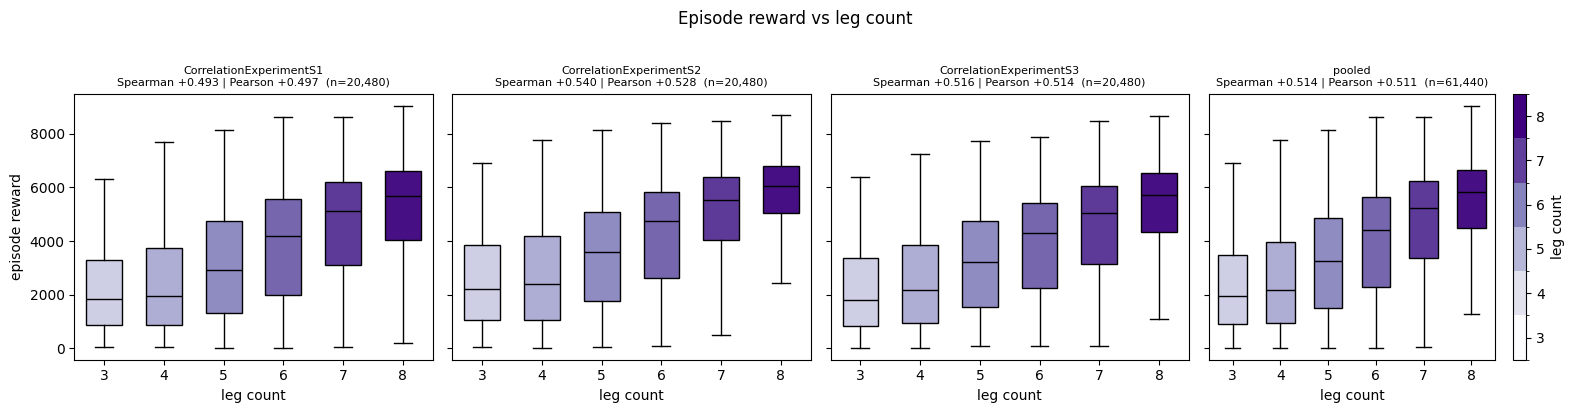

In [4]:
fig, axes = plt.subplots(1, len(df_panels), figsize=(4 * len(df_panels), 4), sharey=True)
for ax, (name, sub) in zip(axes, df_panels):
    bp = ax.boxplot([sub[sub.leg_count == l]["reward"].values for l in LEGS],
                    positions=LEGS, widths=0.6, showfliers=False, patch_artist=True)
    for patch, l in zip(bp["boxes"], LEGS):
        patch.set_facecolor(LEG_COLORS[l])
    for med in bp["medians"]:
        med.set_color("black")
    ax.set_title(f"{name}\n{clabel(sub.leg_count, sub.reward)}", fontsize=8)
    ax.set_xlabel("leg count")
axes[0].set_ylabel("episode reward")
fig.colorbar(leg_sm(), ax=axes[-1], label="leg count", ticks=LEGS)
fig.suptitle("Episode reward vs leg count", y=1.02)
plt.tight_layout(); plt.savefig(OUT_DIR / "reward_vs_legcount.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Episode reward vs segment length (active segments)

**Top:** each env contributes one point per active hip/ankle segment (length paired with its episode
reward); hexbin shading = point density. **Bottom:** marginalized by leg count — mean reward vs binned
length, one line per leg count — so the length effect is read with leg count held fixed.

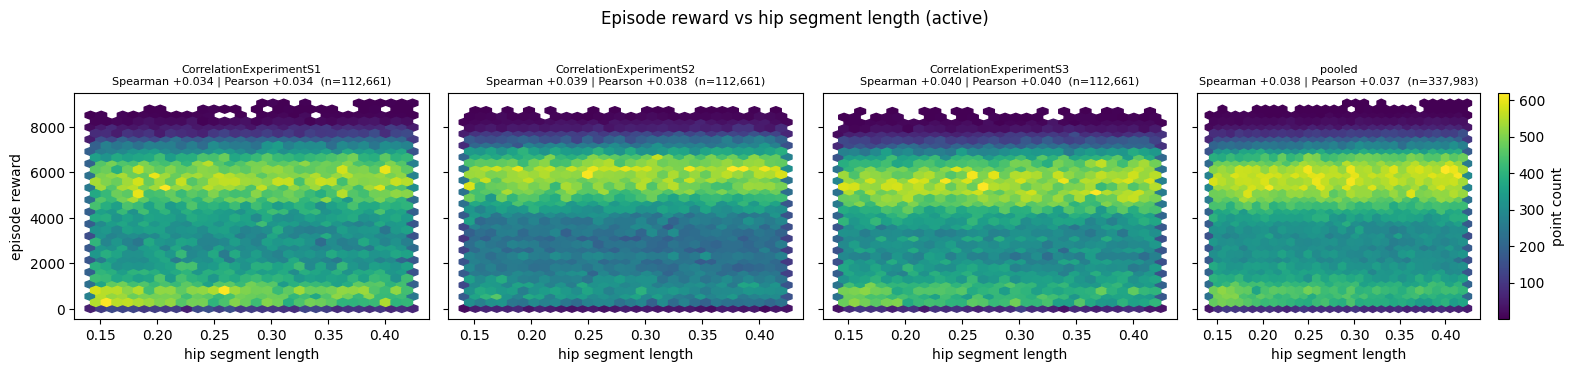

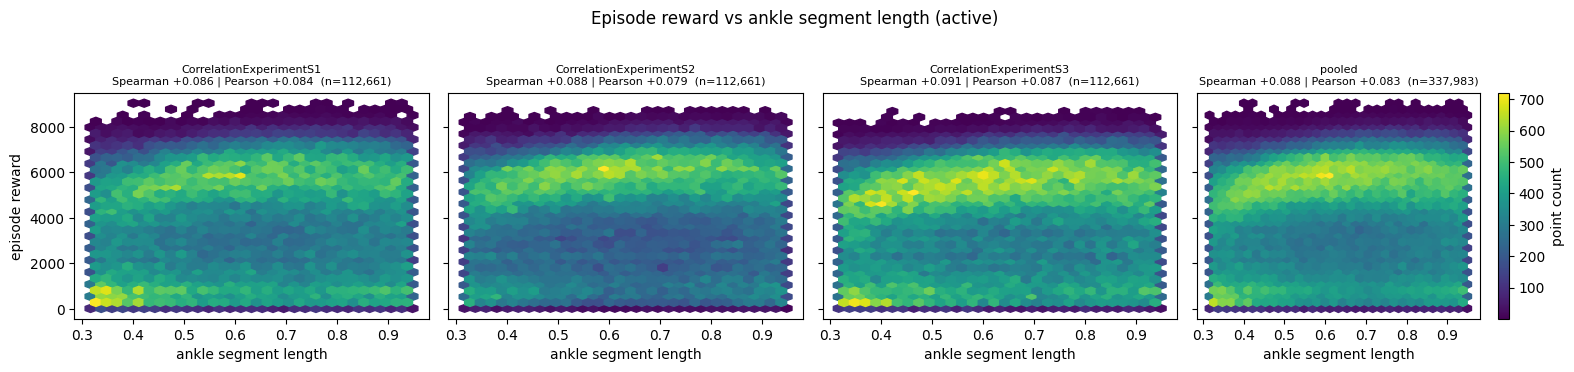

In [5]:
# 2a. per-active-segment density
for which in ("hip", "ankle"):
    fig, axes = plt.subplots(1, len(model_panels), figsize=(4 * len(model_panels), 3.6),
                             sharey=True, sharex=True)
    for ax, (name, subset) in zip(axes, model_panels):
        L, R, _ = seg_long(subset, which, "episode_reward")
        hb = ax.hexbin(L, R, gridsize=30, mincnt=1, cmap="viridis")
        ax.set_title(f"{name}\n{clabel(L, R)}", fontsize=8)
        ax.set_xlabel(f"{which} segment length")
    axes[0].set_ylabel("episode reward")
    fig.colorbar(hb, ax=axes[-1], label="point count")
    fig.suptitle(f"Episode reward vs {which} segment length (active)", y=1.02)
    plt.tight_layout(); plt.savefig(OUT_DIR / f"reward_vs_{which}_len.png", dpi=150, bbox_inches="tight")
    plt.show()

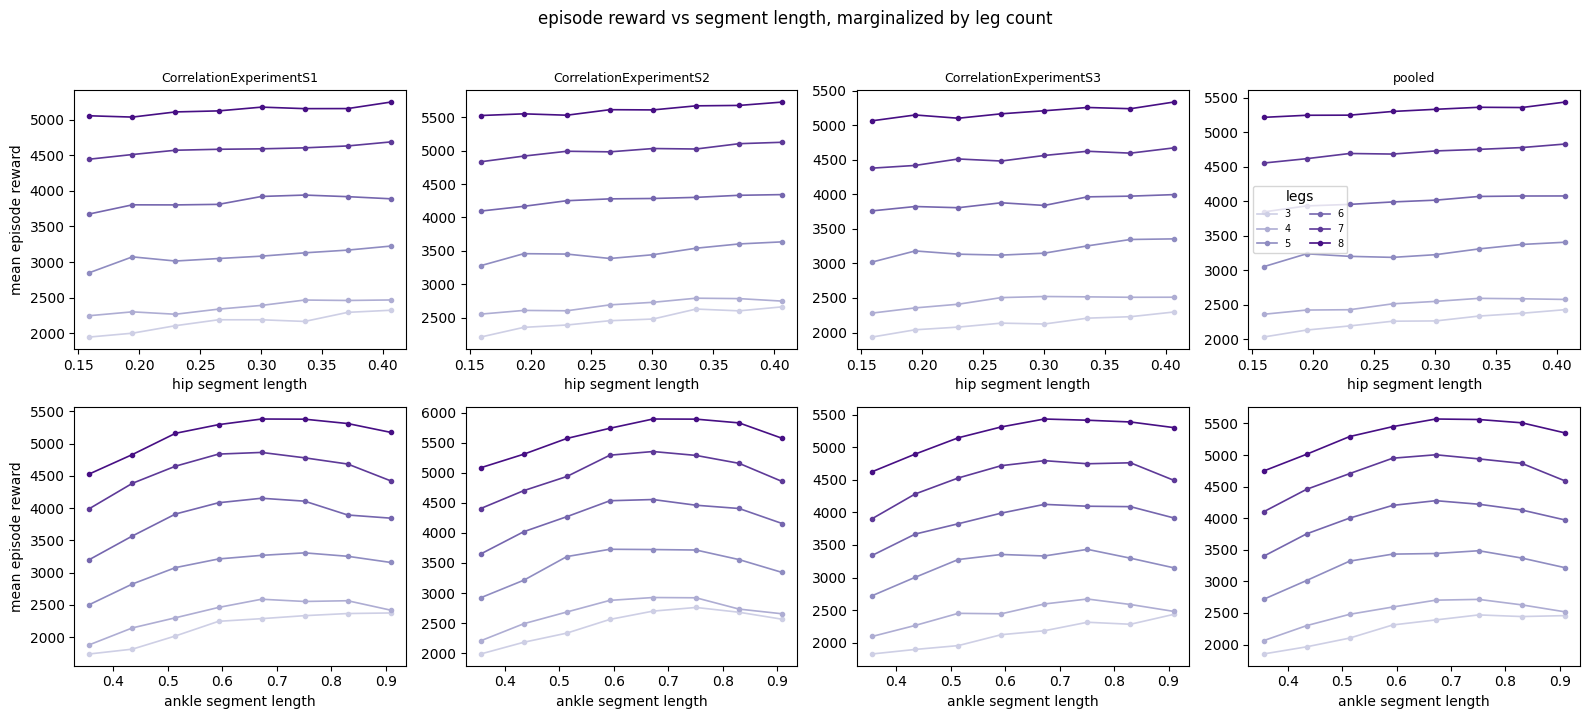

In [6]:
# 2b. marginalized by leg count: mean reward vs length, one line per leg count
def marg_figure(target_key, target_label, fname):
    fig, axes = plt.subplots(2, len(model_panels), figsize=(4 * len(model_panels), 7),
                             sharex="row")
    for r, which in enumerate(("hip", "ankle")):
        for ax, (name, subset) in zip(axes[r], model_panels):
            L, T, C = seg_long(subset, which, target_key)
            marg_lines(ax, L, T, C)
            if r == 0:
                ax.set_title(name, fontsize=9)
            ax.set_xlabel(f"{which} segment length")
        axes[r, 0].set_ylabel(f"mean {target_label}")
    axes[0, -1].legend(title="legs", fontsize=7, ncol=2)
    fig.suptitle(f"{target_label} vs segment length, marginalized by leg count", y=1.02)
    plt.tight_layout(); plt.savefig(OUT_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()

marg_figure("episode_reward", "episode reward", "reward_vs_len_by_legcount.png")

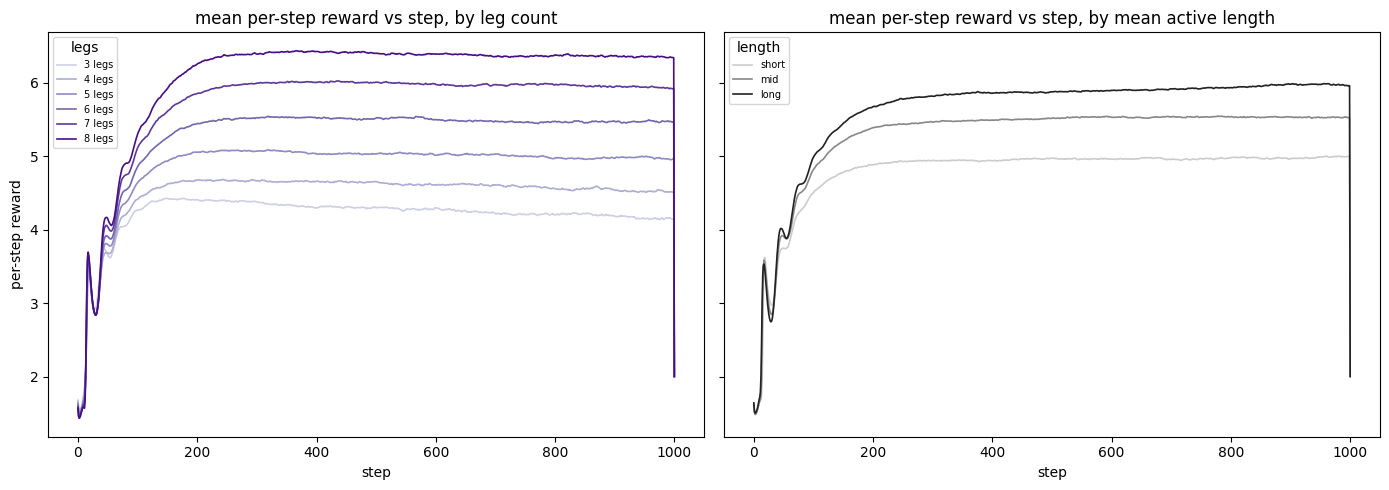

In [7]:
Lmax = max(m["value"].shape[2] for m in models)

def pad_L(a):
    return np.pad(a.astype(np.float32), [(0, 0)] * (a.ndim - 1) + [(0, Lmax - a.shape[-1])],
                  constant_values=np.nan)

V = np.concatenate([pad_L(m["value"]).reshape(-1, Lmax) for m in models])  # [tot, Lmax]
assert V.shape[0] == len(env_df)
lc = env_df["leg_count"].values
mean_len = np.nanmean(env_df[["mean_hip_len", "mean_ankle_len"]].values, axis=1)
length_bucket = pd.qcut(mean_len, 3, labels=["short", "mid", "long"])
TERCILE_C = {"short": "#cccccc", "mid": "#888888", "long": "#222222"}

def plot_trajectories(M, ylabel, fname):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for l in LEGS:
        ax1.plot(np.nanmean(M[lc == l], axis=0), color=LEG_COLORS[l], label=f"{l} legs", lw=1.2)
    ax1.set_title(f"mean {ylabel} vs step, by leg count"); ax1.set_xlabel("step")
    ax1.set_ylabel(ylabel); ax1.legend(title="legs", fontsize=7)
    for b in ("short", "mid", "long"):
        ax2.plot(np.nanmean(M[np.asarray(length_bucket == b)], axis=0),
                 color=TERCILE_C[b], label=b, lw=1.2)
    ax2.set_title(f"mean {ylabel} vs step, by mean active length"); ax2.set_xlabel("step")
    ax2.legend(title="length", fontsize=7)
    plt.tight_layout(); plt.savefig(OUT_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()


R = np.concatenate([pad_L(m["reward_step"]).reshape(-1, Lmax) for m in models])  # [tot, Lmax]
plot_trajectories(R, "per-step reward", "reward_trajectories.png")

In [8]:
# pooled per-step value vs factors (each finite step a point, subsampled for speed)
def pooled_step_corr(M, label):
    rng = np.random.default_rng(0)
    finite = np.isfinite(M)
    v = M[finite]
    lcf = np.repeat(lc[:, None], Lmax, axis=1)[finite]
    mlf = np.repeat(mean_len[:, None], Lmax, axis=1)[finite]
    idx = rng.choice(v.size, size=min(200_000, v.size), replace=False)
    print(f"per-step {label} vs leg count       :", clabel(lcf[idx], v[idx]))
    print(f"per-step {label} vs mean active len :", clabel(mlf[idx], v[idx]))

pooled_step_corr(R, "reward")

per-step reward vs leg count       : Spearman +0.379 | Pearson +0.369  (n=200,000)
per-step reward vs mean active len : Spearman +0.198 | Pearson +0.198  (n=200,000)


## 3. Per-step value: trajectories & correlation

Value traces stacked across models & Samples (row order matches `env_df`). Trajectories use every
finite step (nanmean over envs), leg-count lines in the purple gradient; the pooled correlation
treats each step as a point (subsampled). Also: mean V marginalized by leg count vs segment length.

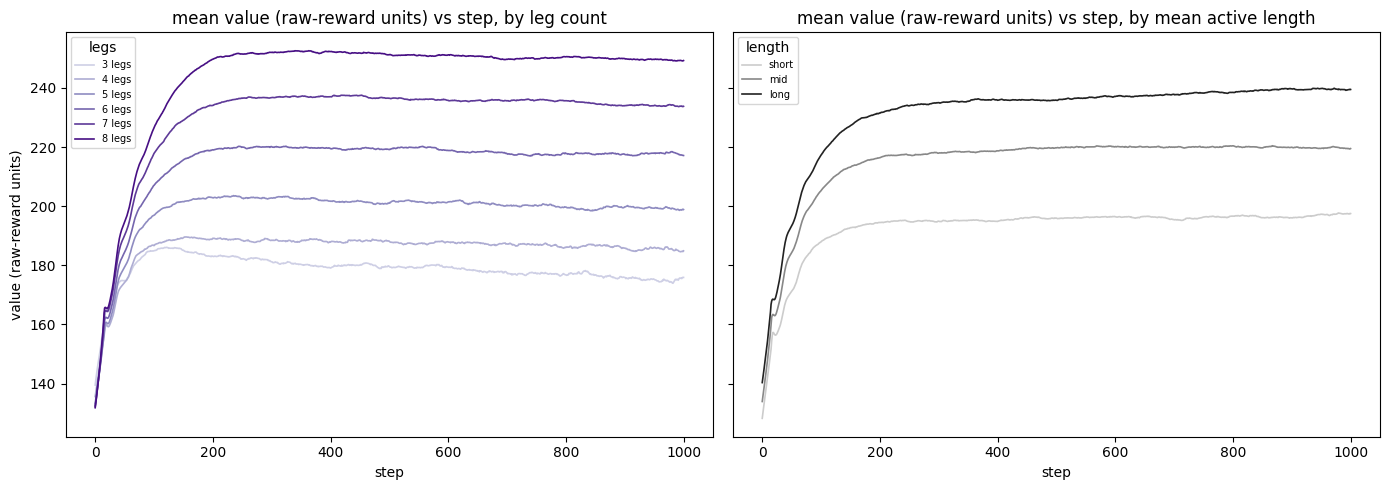

In [9]:
plot_trajectories(V, "value (raw-reward units)", "value_trajectories.png")

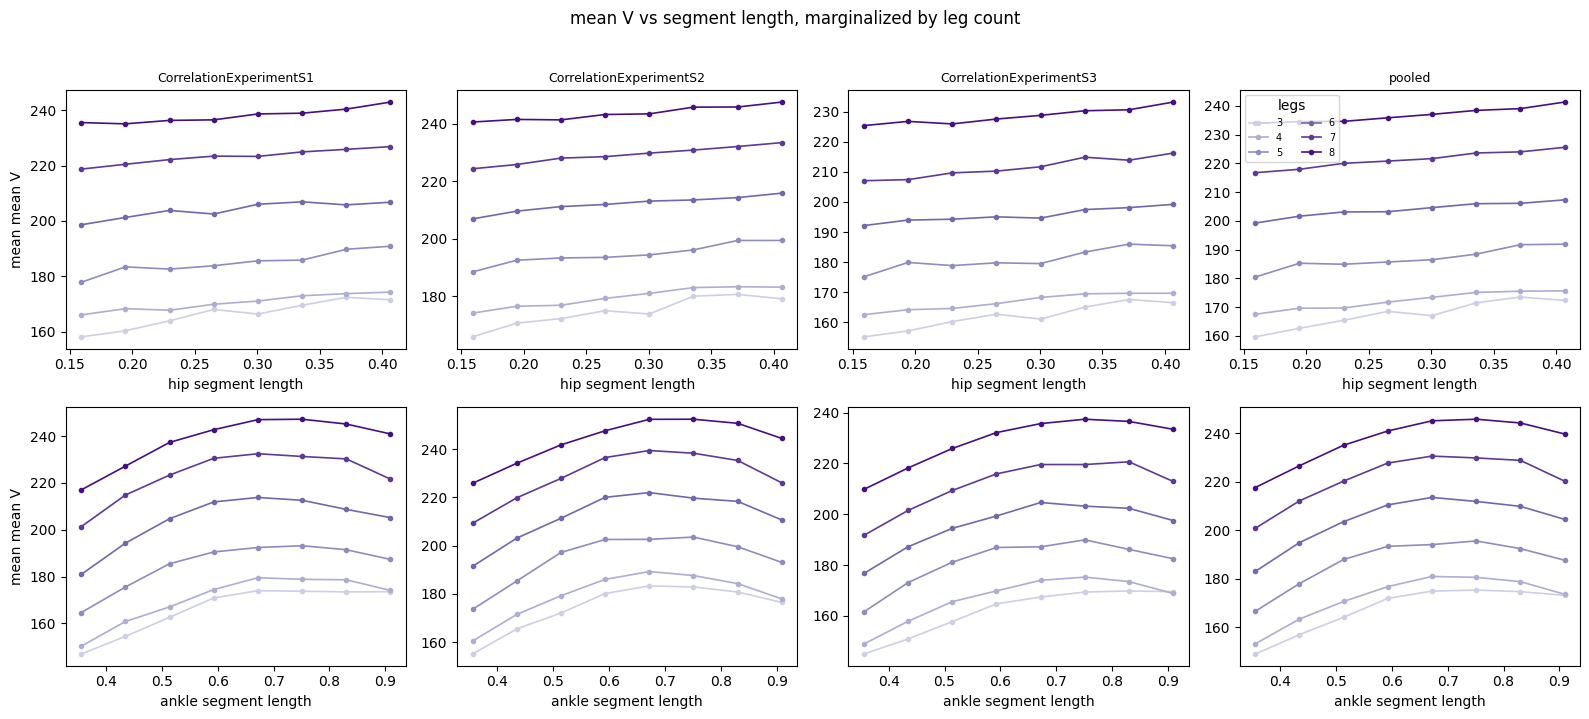

In [10]:
# marginalized mean V vs segment length, by leg count
marg_figure("mean_v", "mean V", "value_vs_len_by_legcount.png")

In [11]:
pooled_step_corr(V, "value")

per-step value vs leg count       : Spearman +0.372 | Pearson +0.348  (n=200,000)
per-step value vs mean active len : Spearman +0.265 | Pearson +0.252  (n=200,000)


## 4. Mean V (over episode) vs episode reward

Does the critic's mean value rank morphs by outcome? Mean V predicts a *discounted* return while
episode reward is the *undiscounted* sum, so expect strong correlation but not the identity line.

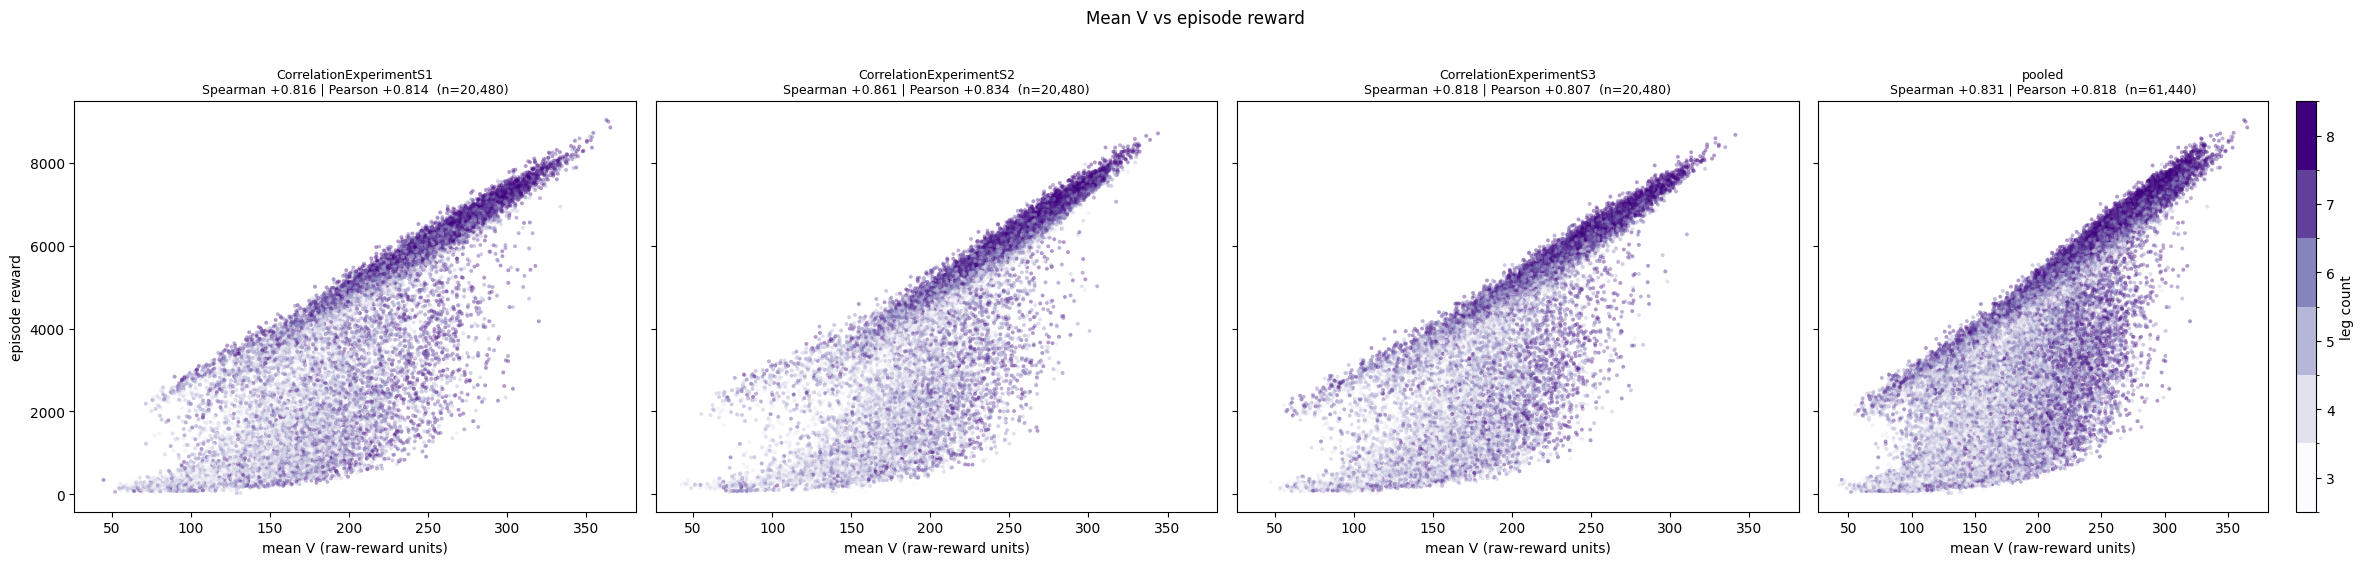

In [12]:
fig, axes = plt.subplots(1, len(df_panels), figsize=(6 * len(df_panels), 5.5),
                         sharey=True, sharex=True)
for ax, (name, sub) in zip(axes, df_panels):
    ax.scatter(sub.mean_v, sub.reward, c=sub.leg_count, cmap=PURPLE, norm=LEG_NORM,
               s=8, alpha=0.4, edgecolors="none")
    ax.set_title(f"{name}\n{clabel(sub.mean_v, sub.reward)}", fontsize=9)
    ax.set_xlabel("mean V (raw-reward units)")
axes[0].set_ylabel("episode reward")
fig.colorbar(leg_sm(), ax=axes[-1], label="leg count", ticks=LEGS)
fig.suptitle("Mean V vs episode reward", y=1.02)
plt.tight_layout(); plt.savefig(OUT_DIR / "mean_v_vs_reward.png", dpi=150, bbox_inches="tight")
plt.show()